In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import typing

In [2]:
# 定义高斯核函数
def k(x:float, mean:float=0, variance:float=1) -> float:
    return 1 / math.sqrt(2 * math.pi * variance) * math.exp(-(x - mean) ** 2 / (2 * variance))

In [3]:
# 定义true density function
def f(x:float) -> float:
    return 0.5 * k(x, mean=-2, variance=1) + 0.5 * k(x, mean=2 ,variance=1)

In [4]:
# 定义 kernel density estimator
def kde_estimator(x: float, data: list, h: float) -> float:
    n = len(data)
    return sum(k((x - xi) / h) for xi in data) / (n * h)

In [5]:
# 定义 L2距离
def l2_error(data: list, h: float, a: float = -10, b: float = 10, num_points: int = 2000) -> float:
    x = np.linspace(a, b, num_points)
    dx = (b - a) / (num_points - 1)

    def kde(x_val):
        return kde_estimator(x_val, data, h)
    
    integrand = 0.0
    for i, xi in enumerate(x):
        diff = kde(xi) - f(xi)
        val = diff * diff * f(xi)
        if i == 0 or i == num_points - 1:
            integrand += 0.5 * val
        else:
            integrand += val
    integrand *= dx
    return np.sqrt(integrand)

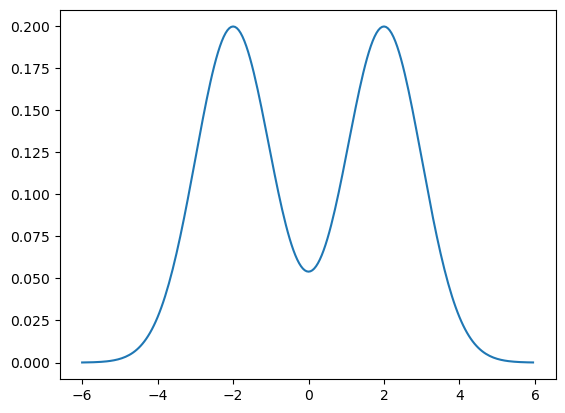

In [6]:
# Task 1
plt.plot(np.arange(-6, 6, 0.05), [f(x) for x in np.arange(-6, 6, 0.05)])
plt.show()

In [7]:
# 生成样本
def generate_samples(n):
    samples = []
    for _ in range(n):
        if np.random.rand() < 0.5:
            samples.append(np.random.normal(-2, 1))
        else:
            samples.append(np.random.normal(2, 1))
    return np.array(samples)

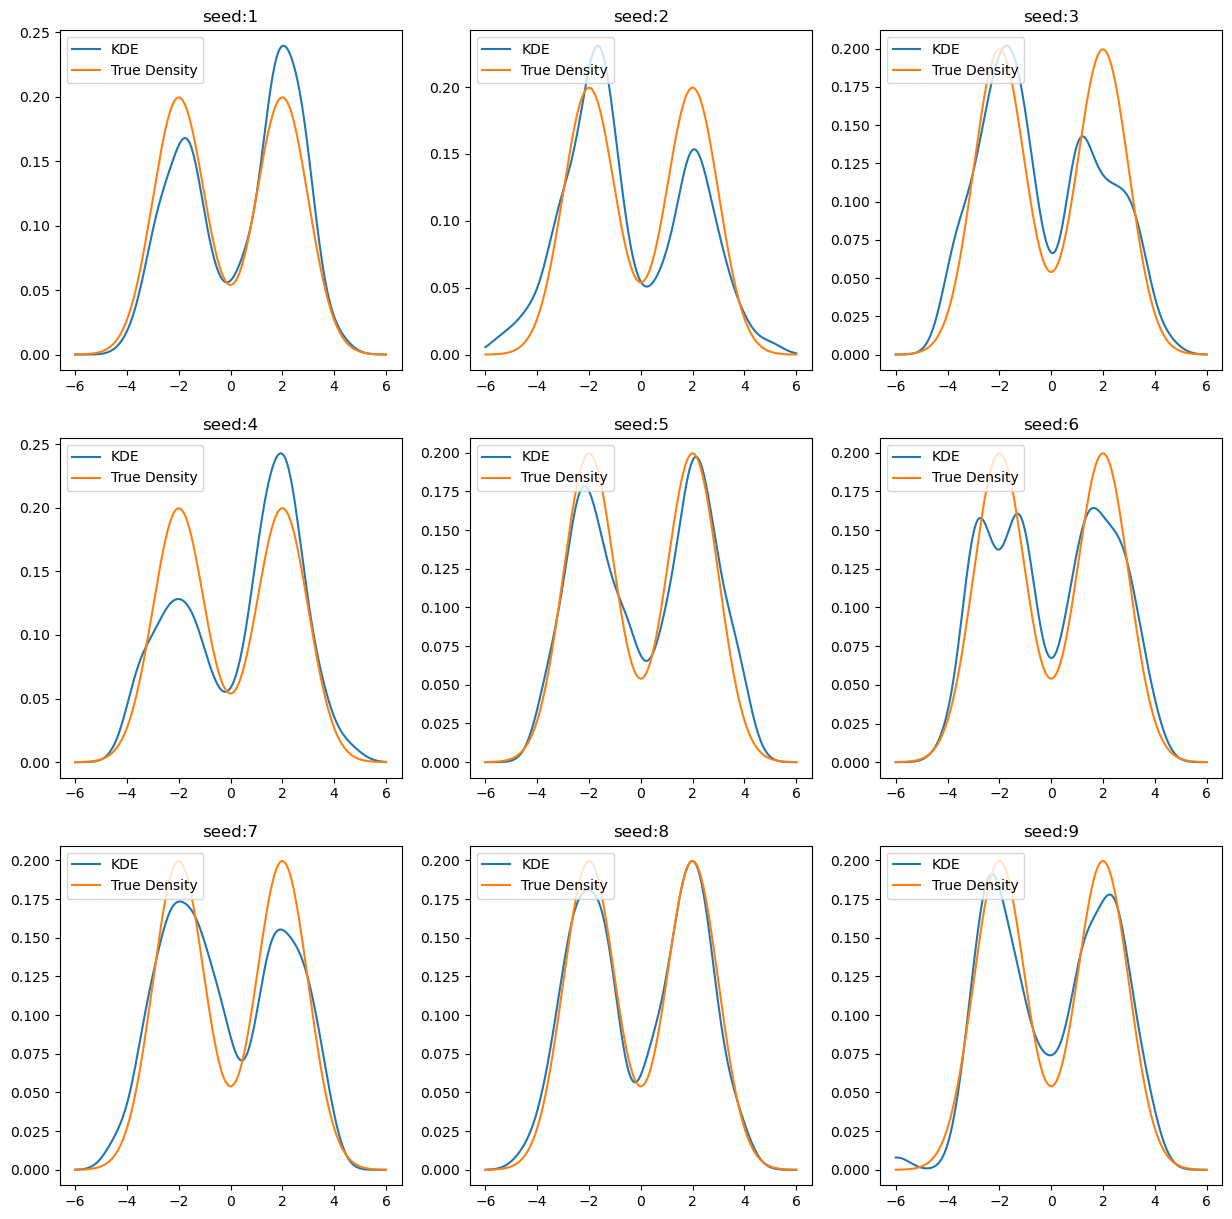

In [16]:
# Task 2
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
x_axis = np.linspace(-6, 6, 500)
for seed in range(1, 10):
    np.random.seed(seed)

    data = generate_samples(100)
    kde = [kde_estimator(x, data, h = 0.5) for x in x_axis]
    true_desnity = [f(x) for x in x_axis]
    row, col = (seed - 1) // 3, (seed - 1) % 3

    ax[row, col].set_title(f"seed:{seed}")
    ax[row, col].plot(x_axis, kde, label="KDE")
    ax[row, col].plot(x_axis, true_desnity, label="True Density")
    ax[row, col].legend(loc="upper left")

plt.show()


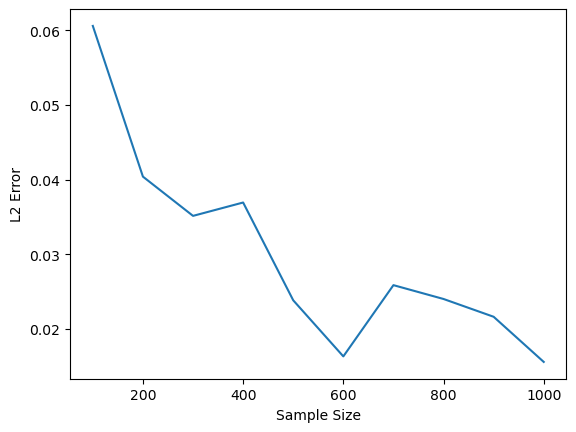

In [9]:
# Task 3
np.random.seed(43)
x_axis = []
y_axis = []
for i in range(1, 11):
    # 样本数量
    n = 100 * i
    x_axis.append(n)
    # 计算L2误差项
    data = generate_samples(n)
    l2 = l2_error(data=data, h=0.1)
    y_axis.append(l2)
plt.plot(x_axis, y_axis)
plt.xlabel("Sample Size")
plt.ylabel("L2 Error")
plt.show()

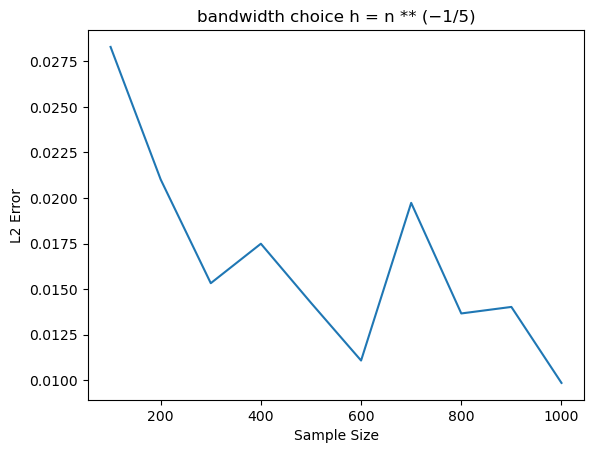

In [10]:
# Task 4
np.random.seed(43)
x_axis = []
y_axis = []
for i in range(1, 11):
    # 样本数量
    n = 100 * i
    x_axis.append(n)
    # 计算L2误差项
    h = n ** (-0.2)
    data = generate_samples(n)
    l2 = l2_error(data=data, h=h)
    y_axis.append(l2)
plt.plot(x_axis, y_axis)
plt.title("bandwidth choice h = n ** (−1/5)")
plt.xlabel("Sample Size")
plt.ylabel("L2 Error")
plt.show()